
# 11. Effect Sizes, Practical Significance, and Decision Thresholds

The previous notebook showed that a study can be statistically significant without automatically justifying action. Now we take the next step: once an effect appears real enough to take seriously, how do we decide whether it is large enough to matter?

That question is central to decision science. A tiny effect can become highly significant in a huge sample, yet still be operationally irrelevant. Conversely, a practically important effect can fail to reach conventional significance in a small, noisy study. To make sound decisions, we need a language that connects estimates to scale, cost, risk, and thresholds for action.

We will use a premium-support example again. An AI triage template appears to reduce ticket-resolution time. The key question is no longer just whether the effect is nonzero. The key question is whether the improvement is large enough, reliable enough, and safe enough to justify rollout.



## Learning Objectives

After working through this lecture, you should be able to:

1. Distinguish statistical significance from practical significance.
2. Compute and interpret raw and standardized effect sizes.
3. Translate a per-ticket improvement into operational and economic value.
4. Define a minimum viable gain using business assumptions and explicit labels together.
5. Use uncertainty intervals and bootstrap distributions to judge whether a practically meaningful threshold is truly supported.
6. Turn effect-size evidence into go, no-go, or staged-rollout recommendations.


In [1]:
# Load the libraries and notebook settings used in the examples below.
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats
from IPython.display import Markdown, display

sns.set_theme(style="whitegrid", context="talk")
pd.options.display.float_format = "{:.4f}".format

from pathlib import Path
import sys


def _find_project_root(start=Path.cwd()):
    """
    Locate the portfolio root so shared notebook helpers import reliably.
    
    Parameters:
        start: Starting path for the upward project-root search.
    
    Returns:
        A `Path` pointing to the nearest portfolio root that contains `notebooks/_shared`; if no such parent is found, the original starting path is returned.
    """

    for candidate in [start, *start.parents]:
        if (candidate / "notebooks" / "_shared").exists():
            return candidate
    return start


PROJECT_ROOT = _find_project_root()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from notebooks._shared.display import smart_display


## 1. Why Effect Sizes Matter

A p-value tells us how unusual the observed data would be under a no-effect benchmark. That is useful, but it does not tell us whether the estimated improvement is large enough to matter in practice.

Here, we will report effect sizes in a business-friendly direction: **positive values mean the AI triage template is better**. If the treatment group resolves tickets faster, then the estimated gain is

$$
\widehat{g} = \bar{x}_{\text{status quo}} - \bar{x}_{\text{AI template}}.
$$

A larger positive value means more minutes saved per ticket. We will also compute a standardized effect size,

$$
\widehat{d} = \frac{\bar{x}_{\text{status quo}} - \bar{x}_{\text{AI template}}}{s_{\text{pooled}}},
$$

which expresses the gain in units of pooled within-group standard deviations. Standardized effect sizes are useful for comparison across studies, but raw domain units often matter more for decisions.


In [2]:
# Define helper functions and reusable utilities for this section.
MONTHLY_TICKET_VOLUME = 18_000
ANALYST_COST_PER_HOUR = 42
FIXED_MONTHLY_PROGRAM_COST = 11_000
MAX_ACCEPTABLE_BREACH_INCREASE_PP = 1.0


def make_triage_value_pilot(
    seed=901,
    n_per_group=240,
    baseline_mean=18.2,
    true_time_saving=0.70,
    sigma=4.9,
):
    """
    Construct the triage value pilot object used in this lecture.
    
    Parameters:
        seed: Random seed used to make the simulation or resampling reproducible.
        n_per_group: Sample size or group size used by the simulation, resampling, or inference step.
        baseline_mean: Control-group or baseline mean used to generate simulated outcomes.
        true_time_saving: Input used by `true_time_saving` in this helper.
        sigma: Outcome standard deviation used to control noise in simulated experiments.
    
    Returns:
        A pandas DataFrame containing simulated pilot outcomes, value metrics, and decision quantities for the AI-template rollout example.
    
    Idea:
        Simulate a pilot where statistical effects also have dollar and service implications, tying practical significance to business value.
    """
    rng = np.random.default_rng(seed)
    frames = []

    for label, mean_shift in [("Status quo", 0.0), ("AI triage template", -true_time_saving)]:
        resolution_minutes = np.clip(rng.normal(baseline_mean + mean_shift, sigma, n_per_group), 2, None)
        complexity = rng.normal(0, 1, n_per_group)
        breach_logit = -1.0 + 0.11 * (resolution_minutes - 18) + 0.25 * complexity
        breach_logit += 0.10 if label == "AI triage template" else 0.0
        breach_prob = 1 / (1 + np.exp(-breach_logit))
        sla_breach = rng.binomial(1, breach_prob)

        frames.append(
            pd.DataFrame(
                {
                    "group": label,
                    "resolution_minutes": resolution_minutes,
                    "sla_breach": sla_breach,
                }
            )
        )

    return pd.concat(frames, ignore_index=True)


def evaluate_effect_sizes(
    frame,
    monthly_ticket_volume=MONTHLY_TICKET_VOLUME,
    analyst_cost_per_hour=ANALYST_COST_PER_HOUR,
    fixed_monthly_program_cost=FIXED_MONTHLY_PROGRAM_COST,
):
    """
    Evaluate effect sizes for model comparison, inference, or decision analysis.
    
    Parameters:
        frame: Input DataFrame or data slice to summarize.
        monthly_ticket_volume: Input used by `monthly_ticket_volume` in this helper.
        analyst_cost_per_hour: Decision-scale quantity used in the cost, value, or operational calculation.
        fixed_monthly_program_cost: Decision-scale quantity used in the cost, value, or operational calculation.
    
    Returns:
        A dictionary of pilot effect-size measures, including raw gain, confidence interval, relative reduction, standardized effect, p-value, and value metrics.
    
    Idea:
        Move beyond significance by calculating effect magnitudes, uncertainty, and practical thresholds in the same decision frame.
    """
    treatment = frame.loc[frame["group"] == "AI triage template", "resolution_minutes"].to_numpy()
    control = frame.loc[frame["group"] == "Status quo", "resolution_minutes"].to_numpy()
    treatment_breach = frame.loc[frame["group"] == "AI triage template", "sla_breach"].to_numpy()
    control_breach = frame.loc[frame["group"] == "Status quo", "sla_breach"].to_numpy()

    mean_t = treatment.mean()
    mean_c = control.mean()
    gain_minutes = mean_c - mean_t
    relative_reduction = gain_minutes / mean_c

    pooled_sd = np.sqrt(
        ((len(treatment) - 1) * treatment.var(ddof=1) + (len(control) - 1) * control.var(ddof=1))
        / (len(treatment) + len(control) - 2)
    )
    cohens_d_gain = gain_minutes / pooled_sd
    probability_ai_faster = (treatment[:, None] < control[None, :]).mean()

    t_stat, p_value = stats.ttest_ind(treatment, control, equal_var=False)
    se = np.sqrt(treatment.var(ddof=1) / len(treatment) + control.var(ddof=1) / len(control))
    df_num = (treatment.var(ddof=1) / len(treatment) + control.var(ddof=1) / len(control)) ** 2
    df_den = (treatment.var(ddof=1) / len(treatment)) ** 2 / (len(treatment) - 1)
    df_den += (control.var(ddof=1) / len(control)) ** 2 / (len(control) - 1)
    df = df_num / df_den
    crit = stats.t.ppf(0.975, df)
    diff_ci_low = (mean_t - mean_c) - crit * se
    diff_ci_high = (mean_t - mean_c) + crit * se
    gain_ci_low = -diff_ci_high
    gain_ci_high = -diff_ci_low

    breach_reduction_pp = 100 * (control_breach.mean() - treatment_breach.mean())
    monthly_labor_savings = gain_minutes * monthly_ticket_volume / 60 * analyst_cost_per_hour
    monthly_net_value = monthly_labor_savings - fixed_monthly_program_cost

    return {
        "mean_status_quo": mean_c,
        "mean_ai_template": mean_t,
        "gain_minutes": gain_minutes,
        "gain_ci_low": gain_ci_low,
        "gain_ci_high": gain_ci_high,
        "relative_reduction": relative_reduction,
        "cohens_d_gain": cohens_d_gain,
        "probability_ai_faster": probability_ai_faster,
        "sla_breach_reduction_pp": breach_reduction_pp,
        "p_value": p_value,
        "monthly_labor_savings": monthly_labor_savings,
        "monthly_net_value": monthly_net_value,
    }


pilot = make_triage_value_pilot()
pilot_metrics = evaluate_effect_sizes(pilot)

pilot_summary = (
    pilot.groupby("group")
    .agg(
        n=("resolution_minutes", "size"),
        mean_minutes=("resolution_minutes", "mean"),
        sd_minutes=("resolution_minutes", "std"),
        median_minutes=("resolution_minutes", "median"),
        sla_breach_rate=("sla_breach", "mean"),
    )
)

smart_display(pilot_summary)

,n,mean_minutes,sd_minutes,median_minutes,sla_breach_rate
group,,,,,
AI triage template,240,17.5436,4.9237,17.8497,0.2750
Status quo,240,18.4925,4.9781,18.7007,0.3083


### Dataset and Experiment Design

The dataset is a simulated premium-support pilot for an AI triage template. It has two groups, status quo and AI template, and two kinds of outcomes. The main efficiency outcome is resolution time in minutes. The guardrail outcome is whether a ticket breached the SLA. This mirrors a real deployment conversation, where faster handling is not enough if quality or reliability deteriorates.

The experiment extends the previous hypothesis-testing setup by adding business scale and cost. We assume monthly premium-ticket volume, analyst cost per hour, recurring program cost, and a maximum acceptable breach increase. Those assumptions let us translate minutes saved per ticket into monthly value and compare the observed gain against a minimum viable gain.

This design forces three languages to meet in one place: statistical effect size, operational units, and business thresholds. The notebook is not asking only whether the template helped. It is asking whether the help is large enough, reliable enough, and safe enough to recommend.


## 2. Raw and Standardized Effect Sizes Tell Different Stories

A single result can look small in standardized units and still matter in domain units. That is especially common in operational systems where outcomes are naturally noisy. A one-minute reduction in resolution time may be a modest fraction of the overall variance, yet still represent a large savings when applied to thousands of tickets.


,metric,value,interpretation
0,Minutes saved per ticket,0.9489,Raw operational improvement; larger is better
1,95% CI for minutes saved,"[0.06, 1.84]",Range of gains still compatible with the data
2,Relative time reduction,0.0513,Share of baseline mean time eliminated
3,Cohen's d (gain direction),0.1917,Standardized effect size in pooled SD units
4,Probability a random AI ticket is faster,0.5556,Common-language effect size
5,SLA breach reduction (percentage points),3.3333,Positive values mean fewer breaches
6,Monthly labor savings at current volume,11956.0731,Gross dollar value before fixed program cost
7,Monthly net value after fixed cost,956.0731,Gross savings minus recurring operating cost
8,Welch test p-value,0.0363,Evidence against a no-gain benchmark


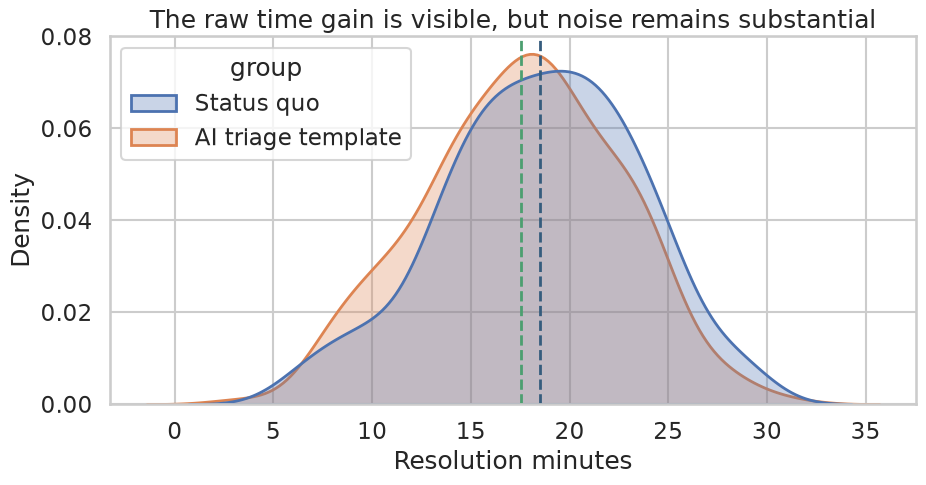

In [3]:
# Visualize the computed results so patterns and diagnostics are easier to interpret.
effect_table = pd.DataFrame(
    [
        {"metric": "Minutes saved per ticket", "value": pilot_metrics["gain_minutes"], "interpretation": "Raw operational improvement; larger is better"},
        {"metric": "95% CI for minutes saved", "value": f"[{pilot_metrics['gain_ci_low']:.2f}, {pilot_metrics['gain_ci_high']:.2f}]", "interpretation": "Range of gains still compatible with the data"},
        {"metric": "Relative time reduction", "value": pilot_metrics["relative_reduction"], "interpretation": "Share of baseline mean time eliminated"},
        {"metric": "Cohen's d (gain direction)", "value": pilot_metrics["cohens_d_gain"], "interpretation": "Standardized effect size in pooled SD units"},
        {"metric": "Probability a random AI ticket is faster", "value": pilot_metrics["probability_ai_faster"], "interpretation": "Common-language effect size"},
        {"metric": "SLA breach reduction (percentage points)", "value": pilot_metrics["sla_breach_reduction_pp"], "interpretation": "Positive values mean fewer breaches"},
        {"metric": "Monthly labor savings at current volume", "value": pilot_metrics["monthly_labor_savings"], "interpretation": "Gross dollar value before fixed program cost"},
        {"metric": "Monthly net value after fixed cost", "value": pilot_metrics["monthly_net_value"], "interpretation": "Gross savings minus recurring operating cost"},
        {"metric": "Welch test p-value", "value": pilot_metrics["p_value"], "interpretation": "Evidence against a no-gain benchmark"},
    ]
)

smart_display(effect_table)

fig, ax = plt.subplots(figsize=(9.6, 5.2))
sns.kdeplot(
    data=pilot,
    x="resolution_minutes",
    hue="group",
    fill=True,
    common_norm=False,
    alpha=0.30,
    linewidth=2,
    ax=ax,
)
ax.axvline(pilot_metrics["mean_status_quo"], color="#355C7D", linestyle="--", linewidth=2)
ax.axvline(pilot_metrics["mean_ai_template"], color="#4C9F70", linestyle="--", linewidth=2)
ax.set_title("The raw time gain is visible, but noise remains substantial")
ax.set_xlabel("Resolution minutes")
ax.set_ylabel("Density")
plt.tight_layout()
plt.show()



This is the central interpretive point. The standardized effect size is modest, because ticket-resolution times are noisy. But the raw gain is close to one minute per ticket, which is not trivial in a high-volume service environment.

This is why standardized labels such as “small” or “medium” should not be treated as decision rules. They can help compare studies, but they do not tell us whether a deployment pays for itself or improves the workflow enough to matter.


## 3. Decision Thresholds Translate Effects into Action Rules

To decide whether the pilot is worth scaling, we need a threshold that comes from operations and business constraints. Suppose the AI triage program has a recurring monthly operating cost of $11{,}000$ and analysts cost $42$ per hour. With $18{,}000$ premium tickets per month, the minimum gain required to break even on labor savings alone is

$$
g_{\min} = \frac{60 \times \text{fixed monthly cost}}{\text{monthly ticket volume} \times \text{hourly analyst cost}}.
$$

This is a minimum viable gain. Any effect smaller than this can still be statistically significant, but it does not yet justify the operating expense.


,assumption,value
0,Monthly premium-ticket volume,18000.0000
1,Loaded analyst cost per hour,42.0000
2,Recurring AI triage operating cost,11000.0000
3,Minimum viable gain for break-even,0.8730


,quantity,value,decision_relevance
0,Observed point-estimate gain,0.9489,Current best estimate of minutes saved per ticket
1,Minimum viable gain,0.8730,Break-even threshold for labor savings alone
2,Point-estimate monthly net value,956.0731,Expected monthly value at current scale if the...
3,Guardrail: maximum acceptable breach increase ...,1.0000,Quality should not worsen by more than this am...


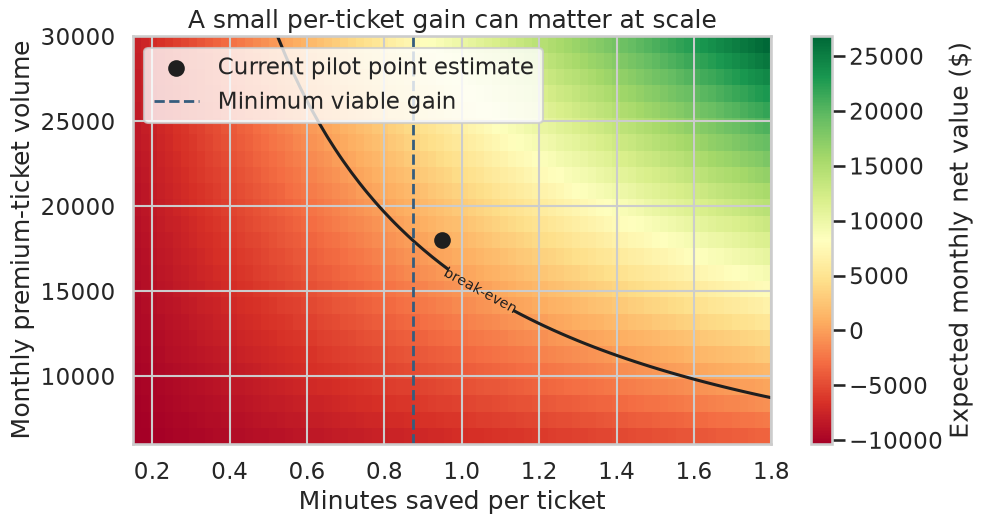

In [4]:
# Visualize the computed results so patterns and diagnostics are easier to interpret.
minimum_viable_gain = 60 * FIXED_MONTHLY_PROGRAM_COST / (MONTHLY_TICKET_VOLUME * ANALYST_COST_PER_HOUR)

assumptions_table = pd.DataFrame(
    {
        "assumption": [
            "Monthly premium-ticket volume",
            "Loaded analyst cost per hour",
            "Recurring AI triage operating cost",
            "Minimum viable gain for break-even",
        ],
        "value": [
            MONTHLY_TICKET_VOLUME,
            ANALYST_COST_PER_HOUR,
            FIXED_MONTHLY_PROGRAM_COST,
            minimum_viable_gain,
        ],
    }
)

decision_threshold_table = pd.DataFrame(
    [
        {
            "quantity": "Observed point-estimate gain",
            "value": pilot_metrics["gain_minutes"],
            "decision_relevance": "Current best estimate of minutes saved per ticket",
        },
        {
            "quantity": "Minimum viable gain",
            "value": minimum_viable_gain,
            "decision_relevance": "Break-even threshold for labor savings alone",
        },
        {
            "quantity": "Point-estimate monthly net value",
            "value": pilot_metrics["monthly_net_value"],
            "decision_relevance": "Expected monthly value at current scale if the point estimate is correct",
        },
        {
            "quantity": "Guardrail: maximum acceptable breach increase (pp)",
            "value": MAX_ACCEPTABLE_BREACH_INCREASE_PP,
            "decision_relevance": "Quality should not worsen by more than this amount",
        },
    ]
)

smart_display(assumptions_table)
smart_display(decision_threshold_table)

volume_grid = np.arange(6_000, 30_001, 1_000)
gain_grid = np.linspace(0.15, 1.80, 80)
net_value_grid = np.outer(volume_grid, gain_grid) * ANALYST_COST_PER_HOUR / 60 - FIXED_MONTHLY_PROGRAM_COST

fig, ax = plt.subplots(figsize=(10.2, 5.6))
image = ax.imshow(
    net_value_grid,
    origin="lower",
    aspect="auto",
    extent=[gain_grid.min(), gain_grid.max(), volume_grid.min(), volume_grid.max()],
    cmap="RdYlGn",
)
zero_contour = ax.contour(
    gain_grid,
    volume_grid,
    net_value_grid,
    levels=[0],
    colors=["#1f1f1f"],
    linewidths=2.2,
)
ax.clabel(zero_contour, fmt={0: "break-even"}, inline=True, fontsize=10)
ax.scatter(
    [pilot_metrics["gain_minutes"]],
    [MONTHLY_TICKET_VOLUME],
    color="#1f1f1f",
    s=110,
    zorder=5,
    label="Current pilot point estimate",
)
ax.axvline(minimum_viable_gain, color="#355C7D", linestyle="--", linewidth=2, label="Minimum viable gain")
ax.set_title("A small per-ticket gain can matter at scale")
ax.set_xlabel("Minutes saved per ticket")
ax.set_ylabel("Monthly premium-ticket volume")
ax.legend(loc="upper left")
fig.colorbar(image, ax=ax, label="Expected monthly net value ($)")
plt.tight_layout()
plt.show()



This figure turns an abstract effect size into an operating map. At higher scale, even modest per-ticket gains can be economically meaningful. At lower scale, the same gain may fail to cover fixed program costs.

The current pilot’s point estimate sits just above the break-even threshold. That is encouraging, but a point estimate alone is not enough. We still need to know how uncertain that practical conclusion is.


## 4. Practical Significance Must Also Survive Uncertainty

An effect can clear the threshold at the point estimate and still fail to support action if the uncertainty is too wide. To study that uncertainty, we bootstrap the pilot by resampling treated and control tickets separately. For each bootstrap sample, we recompute the gain, the standardized effect size, the breach-rate change, and the monthly net value.


,metric,point_estimate,bootstrap_ci_low,bootstrap_ci_high
0,Minutes saved per ticket,0.9489,0.0441,1.8335
1,Cohen's d (gain direction),0.1917,0.0087,0.3711
2,SLA breach reduction (pp),3.3333,-4.5833,11.6667
3,Monthly net value ($),956.0731,-10444.5937,12102.5237


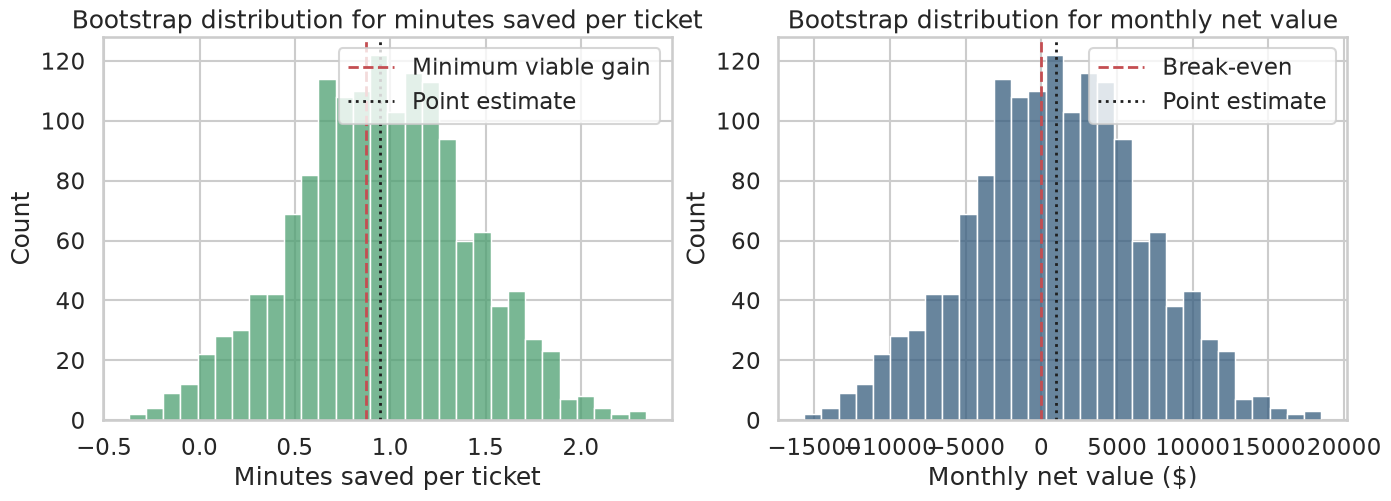

In [5]:
# Define helper functions so repeated calculations stay readable.
def bootstrap_practical_metrics(
    frame,
    reps=1500,
    seed=123,
    monthly_ticket_volume=MONTHLY_TICKET_VOLUME,
    analyst_cost_per_hour=ANALYST_COST_PER_HOUR,
    fixed_monthly_program_cost=FIXED_MONTHLY_PROGRAM_COST,
):
    """
    Generate bootstrap-based practical metrics results from resampled data.
    
    Parameters:
        frame: Input DataFrame or data slice to summarize.
        reps: Number of repeated samples, bootstrap draws, or simulation replications.
        seed: Random seed used to make the simulation or resampling reproducible.
        monthly_ticket_volume: Input used by `monthly_ticket_volume` in this helper.
        analyst_cost_per_hour: Decision-scale quantity used in the cost, value, or operational calculation.
        fixed_monthly_program_cost: Decision-scale quantity used in the cost, value, or operational calculation.
    
    Returns:
        A pandas DataFrame of bootstrap draws for practical-significance metrics such as gain, value, and guardrail outcomes.
    
    Idea:
        Resample the pilot data to quantify uncertainty in effect size, practical value, and decision thresholds at the same time.
    """
    rng = np.random.default_rng(seed)
    treatment = frame.loc[frame["group"] == "AI triage template"].reset_index(drop=True)
    control = frame.loc[frame["group"] == "Status quo"].reset_index(drop=True)

    rows = []
    for _ in range(reps):
        treatment_boot = treatment.iloc[rng.integers(0, len(treatment), len(treatment))]
        control_boot = control.iloc[rng.integers(0, len(control), len(control))]

        gain_minutes = control_boot["resolution_minutes"].mean() - treatment_boot["resolution_minutes"].mean()
        pooled_sd = np.sqrt(
            ((len(treatment_boot) - 1) * treatment_boot["resolution_minutes"].var(ddof=1)
            + (len(control_boot) - 1) * control_boot["resolution_minutes"].var(ddof=1))
            / (len(treatment_boot) + len(control_boot) - 2)
        )
        cohens_d_gain = gain_minutes / pooled_sd
        breach_reduction_pp = 100 * (control_boot["sla_breach"].mean() - treatment_boot["sla_breach"].mean())
        monthly_net_value = gain_minutes * monthly_ticket_volume / 60 * analyst_cost_per_hour - fixed_monthly_program_cost

        rows.append(
            {
                "gain_minutes": gain_minutes,
                "cohens_d_gain": cohens_d_gain,
                "breach_reduction_pp": breach_reduction_pp,
                "monthly_net_value": monthly_net_value,
            }
        )

    return pd.DataFrame(rows)


bootstrap = bootstrap_practical_metrics(pilot)
bootstrap_summary = pd.DataFrame(
    [
        {
            "metric": "Minutes saved per ticket",
            "point_estimate": pilot_metrics["gain_minutes"],
            "bootstrap_ci_low": bootstrap["gain_minutes"].quantile(0.025),
            "bootstrap_ci_high": bootstrap["gain_minutes"].quantile(0.975),
        },
        {
            "metric": "Cohen's d (gain direction)",
            "point_estimate": pilot_metrics["cohens_d_gain"],
            "bootstrap_ci_low": bootstrap["cohens_d_gain"].quantile(0.025),
            "bootstrap_ci_high": bootstrap["cohens_d_gain"].quantile(0.975),
        },
        {
            "metric": "SLA breach reduction (pp)",
            "point_estimate": pilot_metrics["sla_breach_reduction_pp"],
            "bootstrap_ci_low": bootstrap["breach_reduction_pp"].quantile(0.025),
            "bootstrap_ci_high": bootstrap["breach_reduction_pp"].quantile(0.975),
        },
        {
            "metric": "Monthly net value ($)",
            "point_estimate": pilot_metrics["monthly_net_value"],
            "bootstrap_ci_low": bootstrap["monthly_net_value"].quantile(0.025),
            "bootstrap_ci_high": bootstrap["monthly_net_value"].quantile(0.975),
        },
    ]
)

smart_display(bootstrap_summary)

fig, axes = plt.subplots(1, 2, figsize=(13.8, 4.9), constrained_layout=True)

sns.histplot(bootstrap["gain_minutes"], bins=30, color="#4C9F70", edgecolor="white", ax=axes[0])
axes[0].axvline(minimum_viable_gain, color="#C44E52", linestyle="--", linewidth=2, label="Minimum viable gain")
axes[0].axvline(pilot_metrics["gain_minutes"], color="#1f1f1f", linestyle=":", linewidth=2, label="Point estimate")
axes[0].set_title("Bootstrap distribution for minutes saved per ticket")
axes[0].set_xlabel("Minutes saved per ticket")
axes[0].set_ylabel("Count")
axes[0].legend()

sns.histplot(bootstrap["monthly_net_value"], bins=30, color="#355C7D", edgecolor="white", ax=axes[1])
axes[1].axvline(0, color="#C44E52", linestyle="--", linewidth=2, label="Break-even")
axes[1].axvline(pilot_metrics["monthly_net_value"], color="#1f1f1f", linestyle=":", linewidth=2, label="Point estimate")
axes[1].set_title("Bootstrap distribution for monthly net value")
axes[1].set_xlabel("Monthly net value ($)")
axes[1].set_ylabel("Count")
axes[1].legend()

plt.show()


The bootstrap distributions are where practical significance becomes more honest. The point estimate suggests the program may pay for itself, but the uncertainty is wide enough that substantial shortfalls remain plausible. In other words, the pilot is **promising** but not yet **decisive**.

The same logic applies to the guardrail. The point estimate suggests fewer breaches, but the bootstrap interval still allows mild quality deterioration. A decision-maker should care about that possibility even if the average effect looks favorable.


## 5. Statistical Significance and Practical Significance Can Disagree

The cleanest way to see the distinction is to compare three scenarios:

1. the current pilot,
2. a huge study with a tiny effect, and
3. a small study with a potentially meaningful gain.

These scenarios make different mistakes possible. One can be statistically convincing but practically weak; another can be practically promising but statistically underpowered.


,scenario,n_per_group,minutes_saved_per_ticket,cohens_d,p_value,monthly_net_value,statistically_significant,meets_break_even_by_point_estimate
0,Current pilot,240,0.9489,0.1917,0.0363,956.0731,True,True
1,"Huge sample, tiny effect",10000,0.2020,0.0411,0.0036,-8454.3338,True,False
2,"Small sample, meaningful effect",70,1.6342,0.3179,0.0622,9590.7414,False,True


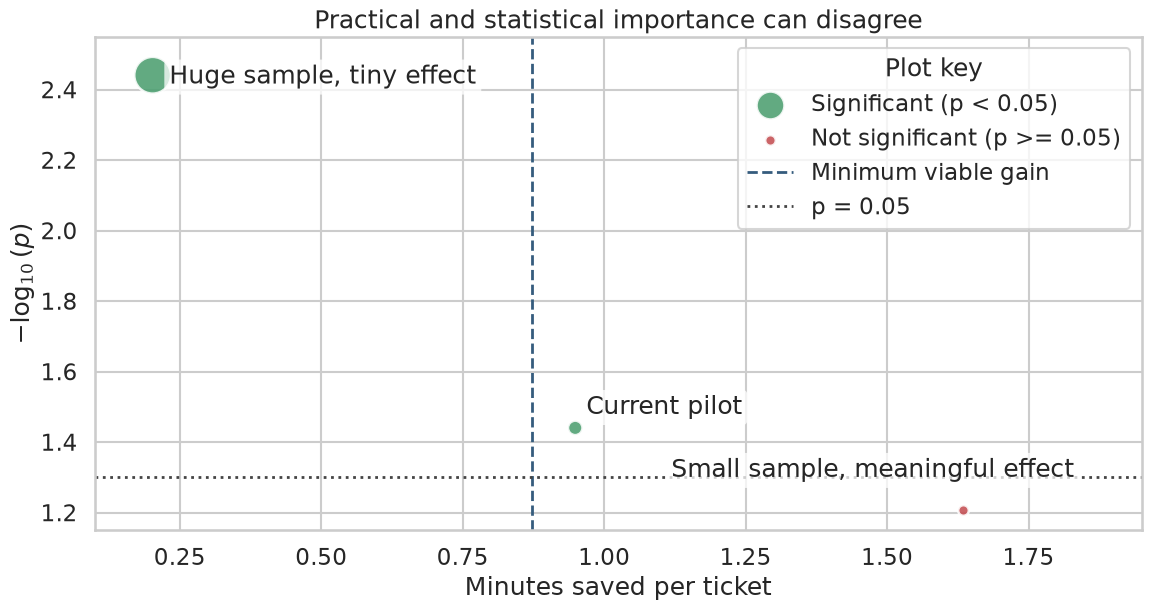

In [6]:
# Define helper functions so repeated calculations stay readable.
def scenario_summary(label, seed, n_per_group, true_time_saving):
    """
    Compute the scenario summary quantity used in the statistical or decision-science workflow.
    
    Parameters:
        label: Human-readable label attached to the returned summary.
        seed: Random seed used to make the simulation or resampling reproducible.
        n_per_group: Sample size or group size used by the simulation, resampling, or inference step.
        true_time_saving: Input used by `true_time_saving` in this helper.
    
    Returns:
        A dictionary summarizing one practical-significance scenario, including sample size, minutes saved, standardized effect, p-value, and net value.
    
    Idea:
        Translate effect-size uncertainty into a small set of action scenarios that can be debated by decision makers.
    """
    frame = make_triage_value_pilot(seed=seed, n_per_group=n_per_group, true_time_saving=true_time_saving)
    metrics = evaluate_effect_sizes(frame)
    return {
        "scenario": label,
        "n_per_group": n_per_group,
        "minutes_saved_per_ticket": metrics["gain_minutes"],
        "cohens_d": metrics["cohens_d_gain"],
        "p_value": metrics["p_value"],
        "monthly_net_value": metrics["monthly_net_value"],
        "statistically_significant": metrics["p_value"] < 0.05,
        "meets_break_even_by_point_estimate": metrics["gain_minutes"] >= minimum_viable_gain,
    }


scenario_table = pd.DataFrame(
    [
        {
            "scenario": "Current pilot",
            "n_per_group": 240,
            "minutes_saved_per_ticket": pilot_metrics["gain_minutes"],
            "cohens_d": pilot_metrics["cohens_d_gain"],
            "p_value": pilot_metrics["p_value"],
            "monthly_net_value": pilot_metrics["monthly_net_value"],
            "statistically_significant": pilot_metrics["p_value"] < 0.05,
            "meets_break_even_by_point_estimate": pilot_metrics["gain_minutes"] >= minimum_viable_gain,
        },
        scenario_summary("Huge sample, tiny effect", seed=5, n_per_group=10_000, true_time_saving=0.12),
        scenario_summary("Small sample, meaningful effect", seed=2, n_per_group=70, true_time_saving=1.00),
    ]
)


smart_display(scenario_table)

plot_table = scenario_table.copy()
plot_table["neg_log10_p"] = -np.log10(plot_table["p_value"])
plot_table["marker_size"] = np.sqrt(plot_table["n_per_group"]) * 7
plot_table["significance_label"] = np.where(
    plot_table["statistically_significant"],
    "Significant (p < 0.05)",
    "Not significant (p >= 0.05)",
)
color_map = {
    "Significant (p < 0.05)": "#4C9F70",
    "Not significant (p >= 0.05)": "#C44E52",
}

fig, ax = plt.subplots(figsize=(11.4, 6.0), constrained_layout=True)
for label, group in plot_table.groupby("significance_label", sort=False):
    ax.scatter(
        group["minutes_saved_per_ticket"],
        group["neg_log10_p"],
        s=group["marker_size"],
        c=color_map[label],
        alpha=0.88,
        edgecolors="white",
        linewidths=1.8,
        label=label,
        zorder=3,
    )

label_offsets = {
    "Current pilot": (8, 10),
    "Huge sample, tiny effect": (12, -6),
    "Small sample, meaningful effect": (-210, 24),
}
for _, row in plot_table.iterrows():
    ax.annotate(
        row["scenario"],
        (row["minutes_saved_per_ticket"], row["neg_log10_p"]),
        xytext=label_offsets[row["scenario"]],
        textcoords="offset points",
        bbox=dict(boxstyle="round,pad=0.2", facecolor="white", edgecolor="none", alpha=0.75),
        zorder=4,
    )

ax.axvline(minimum_viable_gain, color="#355C7D", linestyle="--", linewidth=2, label="Minimum viable gain", zorder=1)
ax.axhline(-np.log10(0.05), color="#444444", linestyle=":", linewidth=2, label="p = 0.05", zorder=1)
ax.set_title("Practical and statistical importance can disagree")
ax.set_xlabel("Minutes saved per ticket")
ax.set_ylabel(r"$-\log_{10}(p)$")
ax.set_xlim(0.10, 1.95)
ax.set_ylim(1.15, 2.55)
ax.legend(loc="upper right", frameon=True, title="Plot key")
plt.show()


The large-sample scenario is statistically convincing but still too small to justify the program economically. The small-sample scenario points toward a meaningful operational gain, yet its p-value is not conventionally significant because the study is too small and too noisy.

This is exactly why decision analysis cannot stop at a significance threshold. Sample size, scale, costs, and uncertainty all shape whether an effect deserves action.


## 6. Misreadings to Avoid

| Tempting shortcut | Why it fails | Better reading |
| --- | --- | --- |
| “The effect is significant, so we should launch.” | Significance does not tell us whether the gain is large enough to matter economically. | Ask whether the estimated gain clears a business threshold and whether the uncertainty supports that conclusion. |
| “Cohen's d is small, so the effect is unimportant.” | Standardized labels ignore domain scale, costs, and deployment volume. | A small standardized effect can still create substantial value in high-volume systems. |
| “The point estimate clears break-even, so the program pays for itself.” | Point estimates ignore uncertainty and guardrail risk. | Check intervals, bootstrap probabilities, and downside scenarios. |
| “A non-significant result means the effect is too small to care about.” | Underpowered studies can miss practically meaningful gains. | Look at effect sizes, thresholds, and study precision before deciding the effect is negligible. |



## 7. Turning Effect Sizes into a Recommendation

We now combine the statistical result, the practical threshold, and the guardrail uncertainty into one recommendation framework.


In [7]:
# Simulate data or resample observations to study variability and uncertainty.
prob_net_positive = (bootstrap["monthly_net_value"] > 0).mean()
prob_guardrail_violation = (bootstrap["breach_reduction_pp"] < -MAX_ACCEPTABLE_BREACH_INCREASE_PP).mean()

recommendation_table = pd.DataFrame(
    [
        {
            "criterion": "Statistical significance",
            "observed_value": pilot_metrics["p_value"],
            "decision_rule": "p-value < 0.05",
            "passes": pilot_metrics["p_value"] < 0.05,
        },
        {
            "criterion": "Point-estimate gain clears break-even",
            "observed_value": pilot_metrics["gain_minutes"],
            "decision_rule": f"Minutes saved >= {minimum_viable_gain:.2f}",
            "passes": pilot_metrics["gain_minutes"] >= minimum_viable_gain,
        },
        {
            "criterion": "Bootstrap probability net value is positive",
            "observed_value": prob_net_positive,
            "decision_rule": "Probability >= 0.80",
            "passes": prob_net_positive >= 0.80,
        },
        {
            "criterion": "Guardrail point estimate does not worsen breaches",
            "observed_value": pilot_metrics["sla_breach_reduction_pp"],
            "decision_rule": "Breach reduction >= 0 pp",
            "passes": pilot_metrics["sla_breach_reduction_pp"] >= 0,
        },
        {
            "criterion": "Bootstrap probability of >1 pp breach increase is low",
            "observed_value": prob_guardrail_violation,
            "decision_rule": "Probability <= 0.10",
            "passes": prob_guardrail_violation <= 0.10,
        },
    ]
)

smart_display(recommendation_table)

if recommendation_table["passes"].all():
    recommendation = (
        "The AI triage template clears the statistical, economic, and guardrail checks. A broader rollout is defensible."
    )
elif (pilot_metrics["gain_minutes"] >= minimum_viable_gain) and (pilot_metrics["p_value"] < 0.05):
    recommendation = (
        "The pilot is **promising but not fully decision-ready**. The point estimate clears break-even and the test is significant, "
        "but the bootstrap evidence is still too fragile for an unconditional rollout. A staged deployment, larger replication, or "
        "focused follow-up experiment would be more defensible than a full launch."
    )
else:
    recommendation = (
        "The current evidence does not support rollout. Either the estimated gain is too small, the uncertainty is too wide, "
        "or the guardrail risk is too high."
    )

smart_display(Markdown(recommendation))


,criterion,observed_value,decision_rule,passes
0,Statistical significance,0.0363,p-value < 0.05,True
1,Point-estimate gain clears break-even,0.9489,Minutes saved >= 0.87,True
2,Bootstrap probability net value is positive,0.5620,Probability >= 0.80,False
3,Guardrail point estimate does not worsen breaches,3.3333,Breach reduction >= 0 pp,True
4,Bootstrap probability of >1 pp breach increase...,0.1400,Probability <= 0.10,False


The pilot is **promising but not fully decision-ready**. The point estimate clears break-even and the test is significant, but the bootstrap evidence is still too fragile for an unconditional rollout. A staged deployment, larger replication, or focused follow-up experiment would be more defensible than a full launch.

The calculation moves the question from statistical detectability to practical value. A small p-value can say that the observed effect is unlikely to be pure noise, but it does not say whether the effect clears the cost, risk, or operational threshold required for action.

This is why the effect-size table belongs in the recommendation. The decision should be based on whether the estimated improvement is large enough, stable enough, and valuable enough to justify the change, not only on whether it is distinguishable from zero.



## Wrap-Up

Effect sizes are where statistical analysis becomes useful for decisions. They help us answer questions that p-values alone cannot:

- How much improvement did we actually estimate?
- Is that improvement meaningful at our operating scale?
- Does the gain survive uncertainty and guardrail checks?
- Should we launch, wait, or gather more evidence?

The right workflow is not “significant versus not significant.” The right workflow is to combine estimated size, uncertainty, operating scale, and downside risk into a threshold-based decision rule.



## References

- Cohen, J. (1994). *The earth is round (p < .05).* American Psychologist, 49(12), 997-1003. [https://doi.org/10.1037/0003-066X.49.12.997](https://doi.org/10.1037/0003-066X.49.12.997)
- Lakens, D. (2013). *Calculating and reporting effect sizes to facilitate cumulative science: A practical primer for t-tests and ANOVAs.* Frontiers in Psychology, 4, 863. [https://doi.org/10.3389/fpsyg.2013.00863](https://doi.org/10.3389/fpsyg.2013.00863)
- Wasserstein, R. L., Schirm, A. L., & Lazar, N. A. (2019). *Moving to a world beyond “p < 0.05”.* The American Statistician, 73(sup1), 1-19. [https://doi.org/10.1080/00031305.2019.1583913](https://doi.org/10.1080/00031305.2019.1583913)
- Torkar, R., Furia, C. A., Feldt, R., de Oliveira Neto, F. G., Gren, L., Lenberg, P., & Ernst, N. A. (2022). *A method to assess and argue for practical significance in software engineering.* IEEE Transactions on Software Engineering, 48(6), 2053-2065. [https://doi.org/10.1109/TSE.2020.3048991](https://doi.org/10.1109/TSE.2020.3048991)
